# Interactive Spinor Rotations

This notebook provides interactive widgets to explore how spinors transform under rotations.

## Key Insight: Spinors Rotate at Half the Angle

When a physical system rotates by angle $\theta$, its spinor representation rotates by $\theta/2$. This is why a $2\pi$ rotation gives a factor of $-1$, and a full return requires $4\pi$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import ipywidgets as widgets
from IPython.display import display, clear_output

# Import spinor visualization
import sys
sys.path.insert(0, '..')
from spinor_viz import Spinor, plot_spinor_3d, plot_spinor_2d
from spinor_viz.core import normalize
from spinor_viz.visualization import create_interactive_3d

%matplotlib inline
plt.rcParams['figure.figsize'] = [10, 8]


## Interactive Rotation Explorer

Use the sliders below to:
- Define the **initial spinor state** (θ and φ angles)
- Choose the **rotation axis** (nx, ny, nz)
- Set the **rotation angle** β

In [ ]:
# Create interactive widgets
style = {'description_width': '120px'}
layout = widgets.Layout(width='400px')

# Initial state controls
theta_slider = widgets.FloatSlider(
    value=60, min=0, max=180, step=5,
    description='θ (polar):', style=style, layout=layout
)
phi_slider = widgets.FloatSlider(
    value=45, min=0, max=360, step=5,
    description='φ (azimuthal):', style=style, layout=layout
)

# Rotation axis controls
axis_x = widgets.FloatSlider(
    value=0, min=-1, max=1, step=0.1,
    description='Axis X:', style=style, layout=layout
)
axis_y = widgets.FloatSlider(
    value=0, min=-1, max=1, step=0.1,
    description='Axis Y:', style=style, layout=layout
)
axis_z = widgets.FloatSlider(
    value=1, min=-1, max=1, step=0.1,
    description='Axis Z:', style=style, layout=layout
)

# Rotation angle
beta_slider = widgets.FloatSlider(
    value=0, min=0, max=720, step=5,
    description='β (rotation):', style=style, layout=layout
)

# View angle
view_elev = widgets.FloatSlider(
    value=20, min=-90, max=90, step=5,
    description='View elevation:', style=style, layout=layout
)
view_azim = widgets.FloatSlider(
    value=25, min=0, max=360, step=5,
    description='View azimuth:', style=style, layout=layout
)

# Output area
output = widgets.Output()


In [3]:
def update_plot(theta, phi, nx, ny, nz, beta, elev, azim):
    """Update the spinor visualization based on widget values."""
    with output:
        clear_output(wait=True)

        # Create initial spinor
        s_initial = Spinor.from_angles(np.radians(theta), np.radians(phi))

        # Normalize rotation axis
        axis = np.array([nx, ny, nz])
        if np.linalg.norm(axis) < 0.01:
            axis = np.array([0, 0, 1])
        axis = normalize(axis)

        # Apply rotation
        s_rotated = s_initial.rotate_axis_angle(axis, np.radians(beta))

        # Create figure
        fig = plt.figure(figsize=(14, 6))
        gs = GridSpec(1, 2, figure=fig)

        # Initial state
        ax1 = fig.add_subplot(gs[0], projection='3d')
        plot_spinor_3d(s_initial, ax=ax1, view_angles=(elev, azim),
                       show_rotation_axis=axis, show_legend=False)
        ax1.set_title(f'Initial State\nθ={theta:.2f}°, φ={phi:.2f}°', fontsize=12)

        # Rotated state
        ax2 = fig.add_subplot(gs[1], projection='3d')
        plot_spinor_3d(s_rotated, ax=ax2, view_angles=(elev, azim),
                       show_rotation_axis=axis)
        ax2.set_title(f'After Rotation by β={beta:.2f}°\naround ({axis[0]:.2f}, {axis[1]:.2f}, {axis[2]:.2f})',
                      fontsize=12)

        plt.tight_layout()
        plt.show()

        # Show spinor values
        print(f"Initial spinor: {s_initial}")
        print(f"Rotated spinor: {s_rotated}")
        print(f"\nBloch vectors:")
        print(f"  Initial: {s_initial.bloch_vector()}")
        print(f"  Rotated: {s_rotated.bloch_vector()}")

        # Check sign flip at 2π
        if abs(beta - 360) < 10:
            phase = s_rotated.components / s_initial.components
            print(f"\n⚠️ Note: After 360° rotation, spinor picks up phase ≈ {np.mean(phase):.3f}")


In [4]:
# Create interactive widget
interactive_plot = widgets.interactive_output(
    update_plot,
    {
        'theta': theta_slider,
        'phi': phi_slider,
        'nx': axis_x,
        'ny': axis_y,
        'nz': axis_z,
        'beta': beta_slider,
        'elev': view_elev,
        'azim': view_azim
    }
)

# Organize layout
initial_box = widgets.VBox([
    widgets.HTML('<b>Initial Spinor State</b>'),
    theta_slider,
    phi_slider
])

axis_box = widgets.VBox([
    widgets.HTML('<b>Rotation Axis</b>'),
    axis_x,
    axis_y,
    axis_z
])

rotation_box = widgets.VBox([
    widgets.HTML('<b>Rotation Angle</b>'),
    beta_slider
])

view_box = widgets.VBox([
    widgets.HTML('<b>View Controls</b>'),
    view_elev,
    view_azim
])

controls = widgets.HBox([initial_box, axis_box])
controls2 = widgets.HBox([rotation_box, view_box])

display(controls, controls2, output)


Output()

## The 4π Periodicity Demonstration

Let's verify that spinors require a 4π rotation to return to their original state:

In [5]:
# Create a spinor and rotate it
s = Spinor.from_angles(np.pi/3, np.pi/4)
axis = np.array([0, 0, 1])  # z-axis

angles = [0, 180, 360, 540, 720]
print("Rotation around z-axis:")
print("="*60)

for angle in angles:
    s_rot = s.rotate_axis_angle(axis, np.radians(angle))

    # Calculate relative phase
    if np.abs(s.up) > 1e-10:
        phase = s_rot.up / s.up
    else:
        phase = s_rot.down / s.down

    print(f"β = {angle:3d}°: phase = {phase: .4f}")

print("\n" + "="*60)
print("After 360°: phase = -1 (spinor flipped sign)")
print("After 720°: phase = +1 (spinor returned to original)")


Rotation around z-axis:
β =   0°: phase =  1.0000-0.0000j
β = 180°: phase =  0.0000-1.0000j
β = 360°: phase = -1.0000-0.0000j
β = 540°: phase = -0.0000+1.0000j
β = 720°: phase =  1.0000+0.0000j

After 360°: phase = -1 (spinor flipped sign)
After 720°: phase = +1 (spinor returned to original)


## Rotation About Different Axes

Let's compare rotations around the three principal axes:

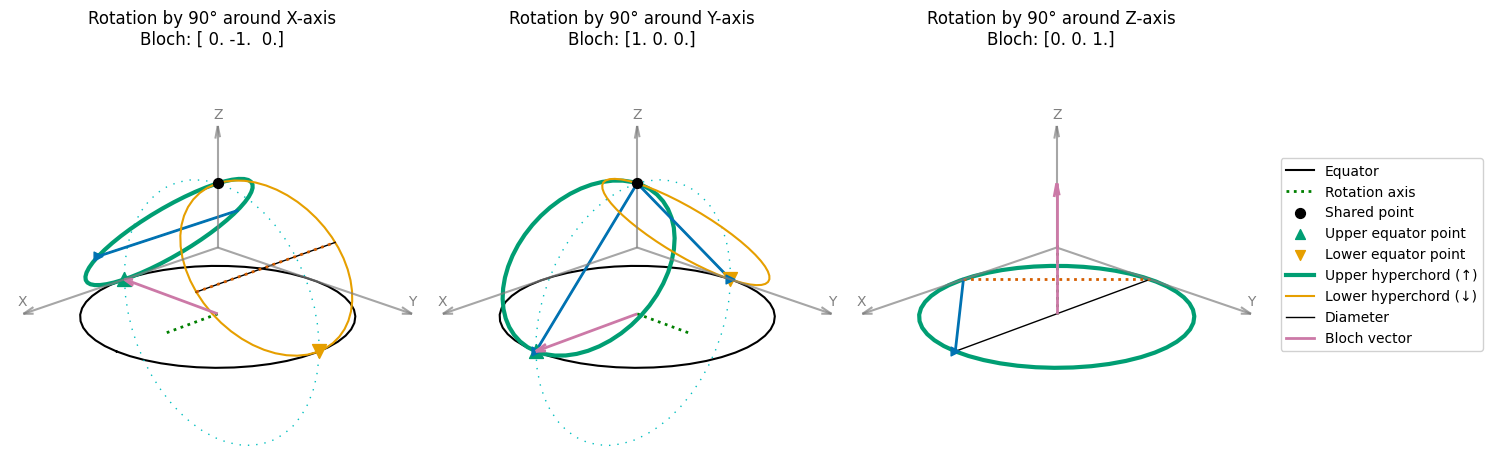

In [6]:
# Initial spin-up state
s = Spinor.spin_up()
angle = np.pi/2  # 90 degrees

fig = plt.figure(figsize=(15, 5))

axes = [
    (np.array([1, 0, 0]), "X-axis"),
    (np.array([0, 1, 0]), "Y-axis"),
    (np.array([0, 0, 1]), "Z-axis")
]

for i, (axis, name) in enumerate(axes):
    s_rot = s.rotate_axis_angle(axis, angle)

    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    plot_spinor_3d(s_rot, ax=ax, show_rotation_axis=axis, view_angles=(20, 45), show_legend=(i+1)%len(axes)==0)
    ax.set_title(f'Rotation by 90° around {name}\nBloch: {s_rot.bloch_vector().round(3)}')

plt.tight_layout()
plt.show()


## Exercise: Verify the Rotation Formula

The SU(2) rotation operator is:

$$R(\hat{n}, \theta) = e^{-i\frac{\theta}{2}\hat{n}\cdot\vec{\sigma}} = \cos\frac{\theta}{2} I - i\sin\frac{\theta}{2}(n_x\sigma_x + n_y\sigma_y + n_z\sigma_z)$$

Let's verify this formula numerically:

In [7]:
from spinor_viz.core import spinor_rotation, pauli
from scipy.linalg import expm

# Rotation parameters
theta = np.pi/3  # 60 degrees
n = normalize(np.array([1, 1, 1]))  # Diagonal axis

# Method 1: Using our spinor_rotation function
R1 = spinor_rotation(n * theta)

# Method 2: Direct formula
R2 = (np.cos(theta/2) * pauli(0) -
      1j * np.sin(theta/2) * (n[0]*pauli(1) + n[1]*pauli(2) + n[2]*pauli(3)))

print("Rotation matrix from spinor_rotation:")
print(R1.round(6))
print("\nRotation matrix from direct formula:")
print(R2.round(6))
print(f"\nDifference: {np.max(np.abs(R1 - R2)):.2e}")


Rotation matrix from spinor_rotation:
[[ 0.866025-0.288675j -0.288675-0.288675j]
 [ 0.288675-0.288675j  0.866025+0.288675j]]

Rotation matrix from direct formula:
[[ 0.866025-0.288675j -0.288675-0.288675j]
 [ 0.288675-0.288675j  0.866025+0.288675j]]

Difference: 1.24e-16


## Next Steps

Continue to:
- **[03_animations.ipynb](03_animations.ipynb)** - Animated spinor evolution under continuous rotation
- **[04_quantum_gates.ipynb](04_quantum_gates.ipynb)** - Quantum gates and their spinor representations